# Aplicação estratégica — revisão científica

**CRISP-DM: Evaluation.** Entregável: respostas às cinco perguntas do PDF, com revisão de validade.
Decisão: manter análise retrospectiva e cenários condicionais; uso prospectivo operacional depende de nova validação.

## 1. Quais fatores estão associados à alfabetização?

O classificador usa contexto educacional e territorial. As participações abaixo descrevem
a contribuição SHAP do modelo salvo, não efeitos de intervenções.

| Família | Participação no SHAP absoluto agrupado |
|---|---:|
| historico_municipal | 57,2% |
| territorial | 27,6% |
| estrutural | 9,1% |
| metas | 4,8% |
| historico_escolar | 1,3% |

A interpretação é exploratória: a seleção histórica de atributos usou a coorte inteira.
Não há dados socioeconômicos ou medidas individuais de renda, frequência e trajetória.
O histórico escolar verdadeiro não foi avaliado: o identificador de escola é reciclado entre edições.

## 2. Quais municípios apresentam maior risco?

O ranking contém 5517 municípios, com escores out-of-fold por município.
Os hiperparâmetros e atributos não foram selecionados de forma aninhada nesses folds;
o escore nacional é descritivo, não uma avaliação confirmatória.

Há duas ordenações: intensidade da taxa e volume estimado. Entre os territórios com posição
publicada, o total é 837.463 crianças em risco contextual estimado;
o top 50 por volume concentra 242.714.
Isso usa pesos de não resposta e supõe representatividade dos presentes dentro dos estratos.
Não identifica quais crianças ausentes terão o desfecho nem demonstra benefício de uma intervenção.

AC e DF permanecem sem posição publicada, por cobertura e desempenho limitados. Roraima não está na base.
`taxa_presenca_2024` e `n_alunos_avaliados` acompanham cada linha.
`faixa_shap_taxa_municipal` marca apenas taxa anterior abaixo de 65% ou ausente.
Uma contribuição SHAP plana de um atributo não comprova perda de ordenação do modelo completo.
`incerteza_posicao_quantificada = False`: a estabilidade de posições próximas ainda não foi medida.

## 3. Quais regiões apresentam padrões semelhantes?

KMeans descritivo em 5461 municípios; k=3,
silhueta 0,2487, escolhida entre 3 e 8.
Há 56 municípios excluídos por campos faltantes.
Os grupos se sobrepõem; são perfis exploratórios de 2024, não classes naturais ou permanentes.
As taxas abaixo são médias simples entre municípios do perfil, não taxas populacionais da região.

| Perfil | Municípios | Média municipal da taxa de 2024 |
|---|---:|---:|
| alfabetização consolidada | 378 | 92,6% |
| faixa intermediária | 2941 | 73,4% |
| risco alto e cobertura menor | 2142 | 43,9% |

## 4. Como analisar metas futuras?

**Gap de esforço:** meta de 2025 menos taxa de 2024, na mesma apuração municipal do INEP.
São 5352 municípios com meta e dados disponíveis;
165 ficam fora. Gap mediano de 2,24 pp;
43,4% já superam essa meta com a taxa de 2024.
É uma diferença observada, sujeita à qualidade e comparabilidade das duas medidas.

**Projeção:** persistência suavizada e deriva estimadas na transição 2023→2024.
O prior, a suavização, a deriva e a dispersão são aprendidos só nos municípios de treino de cada fold.
O porte usado para prever 2024 é de 2023. A prevalência do baseline também vem só do treino.
A aplicação a 2025 usa taxa e porte de 2024, com parâmetros refitados no histórico disponível.

A distribuição de trabalho é T=clip(Z,0,100), com Z normal. `projecao_2025` é sua mediana;
os limites são quantis de 2,5% e 97,5% dessa distribuição. A probabilidade de ficar abaixo
da meta é calculada com a mesma distribuição, respeitando as massas em 0 e 100.
`dp_latente_pp` é a dispersão de Z, não o desvio da taxa censurada.
A estimação da dispersão gaussiana é uma aproximação; a cobertura é avaliada empiricamente.

### Avaliação fora do ajuste

Cinco folds por município na mesma transição anual, com 4611 municípios.
**Não é um teste em ano futuro.** A disponibilidade histórica das publicações ainda precisa ser confirmada.

| Métrica | Valor | Intervalo bootstrap de 95% |
|---|---:|---|
| ROC-AUC | 0,5455 | [0,5283; 0,5631] |
| Brier | 0,24751 | [0,24474; 0,25019] |
| Ganho de Brier sobre prevalência do treino | 0,00142 | [-0,00157; 0,00433] |
| Cobertura do intervalo nominal de 95% | 94,60% | [93,95%; 95,21%] |

Os intervalos usam 1.000 reamostragens de municípios das predições OOF fixadas.
Não incluem incerteza de refit nem mudanças temporais; os folds compartilham parte do treino.
O ganho de Brier inclui zero. A evidência não sustenta superioridade operacional sobre o baseline.
Os métodos testados discriminam pouco; isso não prova que metas sejam intrinsecamente imprevisíveis.

### Cenários de 2025 e horizonte de 2030

Nos cenários de 2025, a largura mediana é 52,0 pp.
A meta fica dentro do intervalo em 97,53% dos municípios.
Os 132 casos fora do intervalo são resultados condicionais ao modelo,
sem garantia de ocorrência. Não se publica rótulo de sucesso ou fracasso.

O porte de referência calculado é 129 alunos,
onde a²/n=c². É uma descrição da curva ajustada; não identifica causas da variação
nem determina quando um município pode ser avaliado individualmente. A coluna
`porte_abaixo_referencia_dispersao` é descritiva e não deve restringir acesso a políticas.

Mantendo a taxa de 2024 constante, 21,3% já satisfariam a meta de 2030.
O gap mediano até 2030 é 15,75 pp em seis anos,
equivalente a 2,625 pp/ano numa divisão linear.
Esse exercício não é previsão da taxa de 2030. Mediana de gaps e deriva ponderada têm agregações distintas;
não se interpreta sua razão como multiplicador de esforço nacional.

## 5. Quais variáveis mais influenciam o modelo?

Média de português municipal, contexto de UF e taxa municipal anterior estão entre as principais.
Consulte `interpret_familias.csv`, `interpret_permutacao.csv` e `interpretabilidade.md`.
Importância é condicionada ao conjunto de atributos e à amostra, com forte correlação entre medidas.
O histórico escolar não é verificável; presença anterior é associação entre os observados,
sem identificação do desfecho dos ausentes.

## Reprodução e limites

`python -m src.modeling.strategic` seguido de `python scripts/atualizar_relatorios.py`.
`estrategia_metas_oof.csv` registra município e fold; `estrategia_validacao_metas.csv`, os decis.
O resumo anterior está em `reports/metrics/historico/` para rastreabilidade.
O modelo individual continua histórico e exploratório; veja `revisao_cientifica.md`.
Não há validação temporal completa, dados socioeconômicos, avaliação causal ou incerteza das posições.


In [1]:
from pathlib import Path
import sys, json
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
import pandas as pd
from IPython.display import display
from src import config, eda
from src.modeling import strategic as st
from src.visualization import plots_estrategia as plots
eda.aplicar_estilo()
resumo = json.loads(st.JSON_ESTRATEGIA.read_text(encoding="utf-8"))
ranking = pd.read_csv(st.CSV_RANKING)
metas = pd.read_csv(st.CSV_METAS)
display(pd.DataFrame(resumo["metas"]["validacao_municipal_2023_2024"]["intervalos_bootstrap"]).T)
display(metas[["projecao_2025", "intervalo_2025_inferior", "intervalo_2025_superior"]].agg(["min", "max"]))


,pontual,ic_baixo,ic_alto
roc_auc,0.545470,0.528292,0.563107
brier,0.247505,0.244736,0.250189
ganho_brier_sobre_baseline,0.001417,-0.001575,0.004331
cobertura_intervalo_95,0.945999,0.939493,0.952077


,projecao_2025,intervalo_2025_inferior,intervalo_2025_superior
min,15.605389,0.000000,40.428324
max,100.000000,80.850213,100.000000


images/estrategia/01_dois_rankings.png


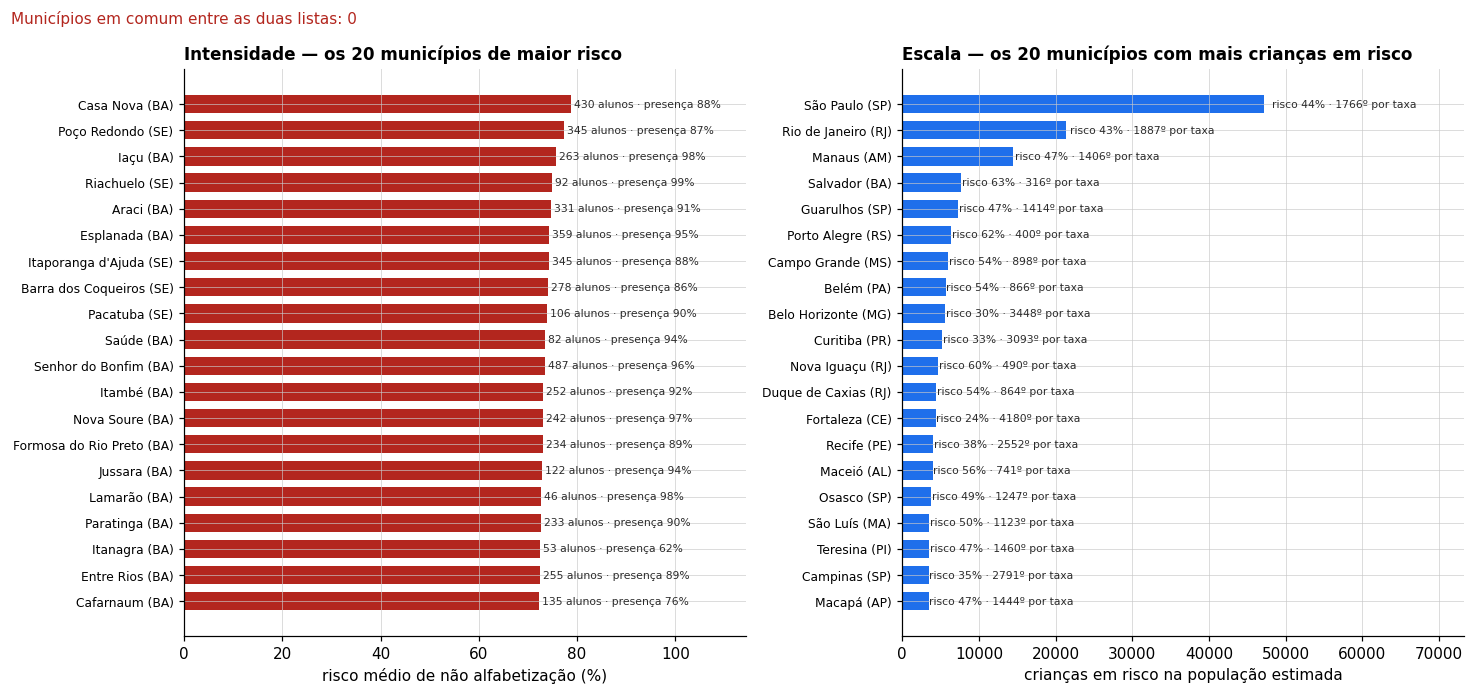

In [2]:
fig = plots.plotar_dois_rankings(ranking)
print(plots.salvar_figura(fig, "01_dois_rankings"))

images/estrategia/02_taxa_versus_volume.png


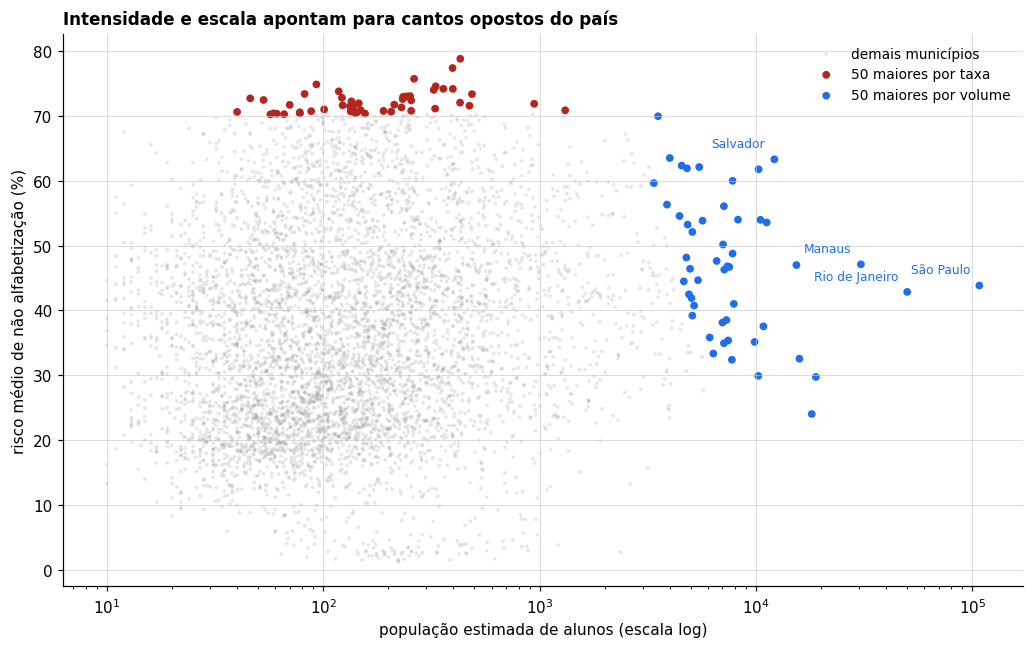

In [3]:
fig = plots.plotar_taxa_versus_volume(ranking)
print(plots.salvar_figura(fig, "02_taxa_versus_volume"))

images/estrategia/03_shrinkage.png


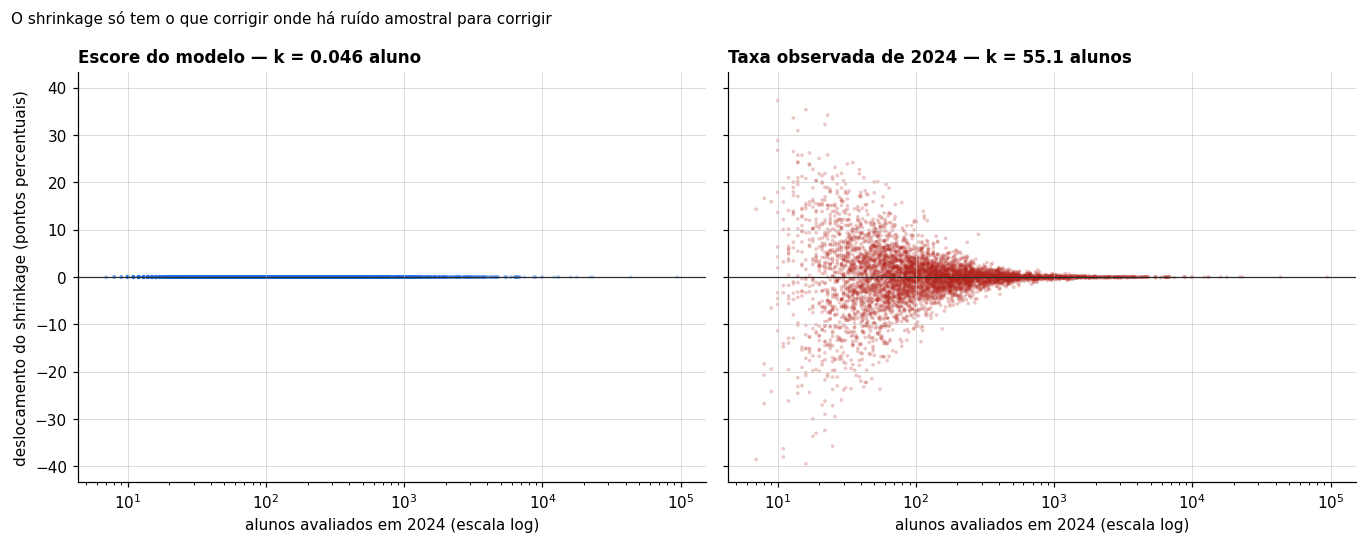

In [4]:
fig = plots.plotar_shrinkage(ranking, pd.read_csv(st.CSV_SHRINKAGE))
print(plots.salvar_figura(fig, "03_shrinkage"))

images/estrategia/04_risco_e_presenca.png


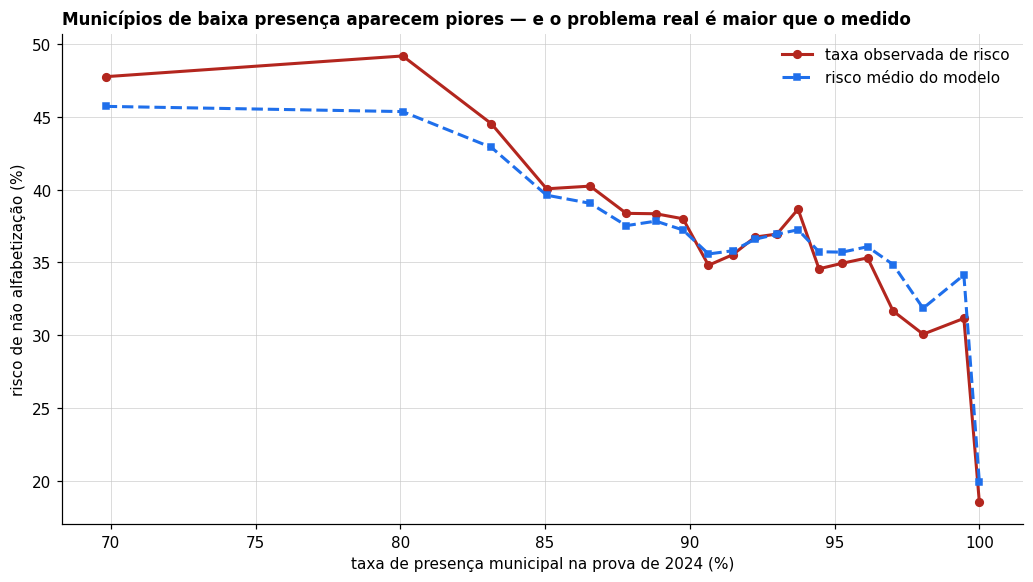

In [5]:
fig = plots.plotar_risco_e_presenca(ranking)
print(plots.salvar_figura(fig, "04_risco_e_presenca"))

images/estrategia/05_selecao_de_k.png


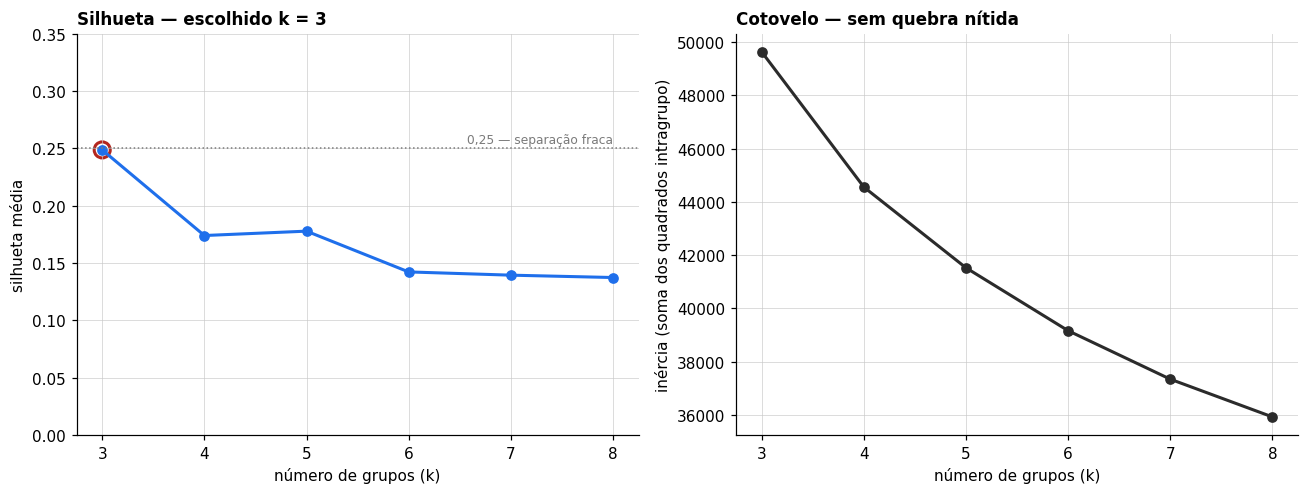

In [6]:
fig = plots.plotar_selecao_de_k(pd.read_csv(st.CSV_SELECAO_K))
print(plots.salvar_figura(fig, "05_selecao_de_k"))

images/estrategia/06_perfil_dos_clusters.png


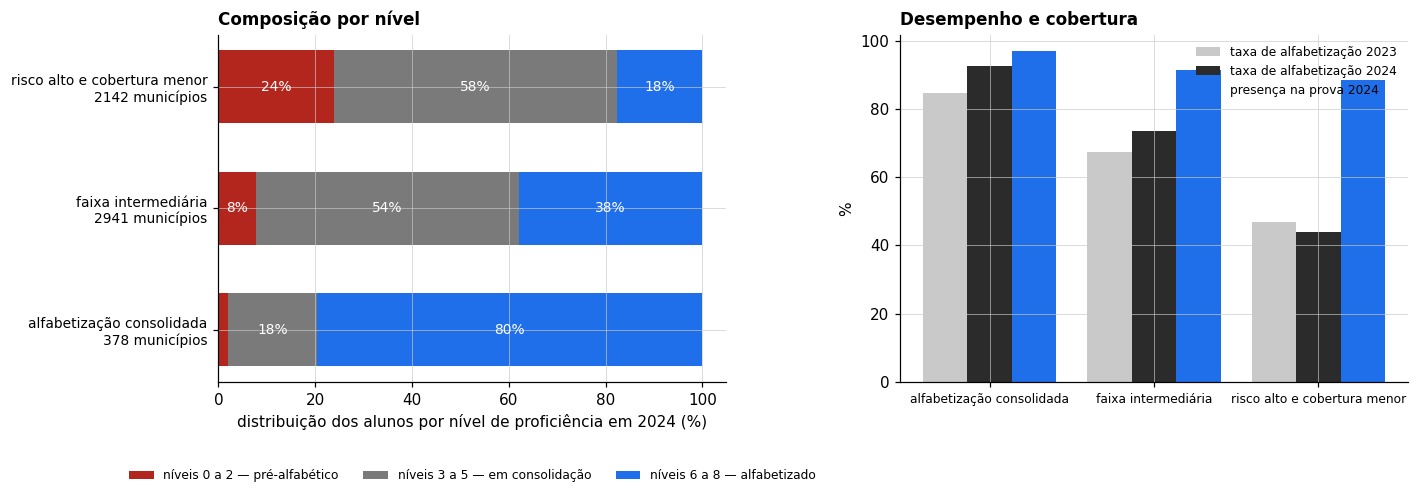

In [7]:
fig = plots.plotar_perfil_dos_clusters(pd.read_csv(st.CSV_PERFIL_CLUSTERS))
print(plots.salvar_figura(fig, "06_perfil_dos_clusters"))

images/estrategia/07_composicao_regional.png


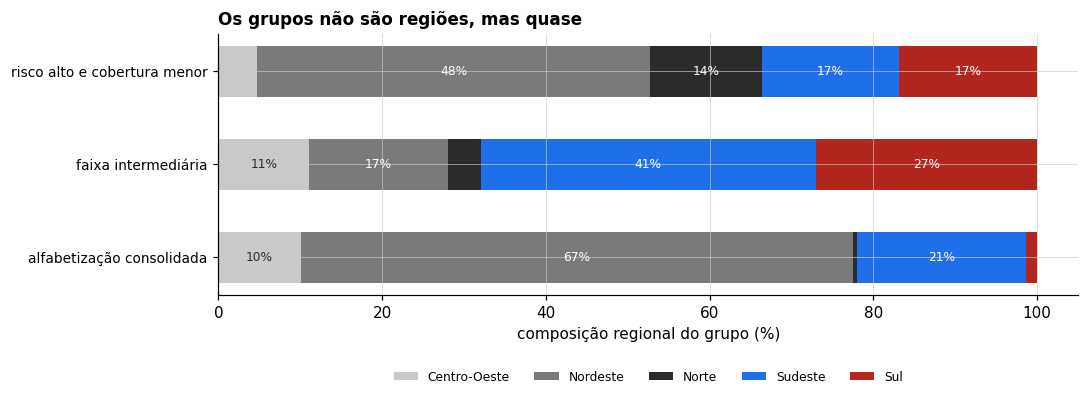

In [8]:
fig = plots.plotar_composicao_regional(pd.read_csv(st.CSV_REGIAO_CLUSTERS), pd.read_csv(st.CSV_PERFIL_CLUSTERS))
print(plots.salvar_figura(fig, "07_composicao_regional"))

images/estrategia/08_gap_de_esforco.png


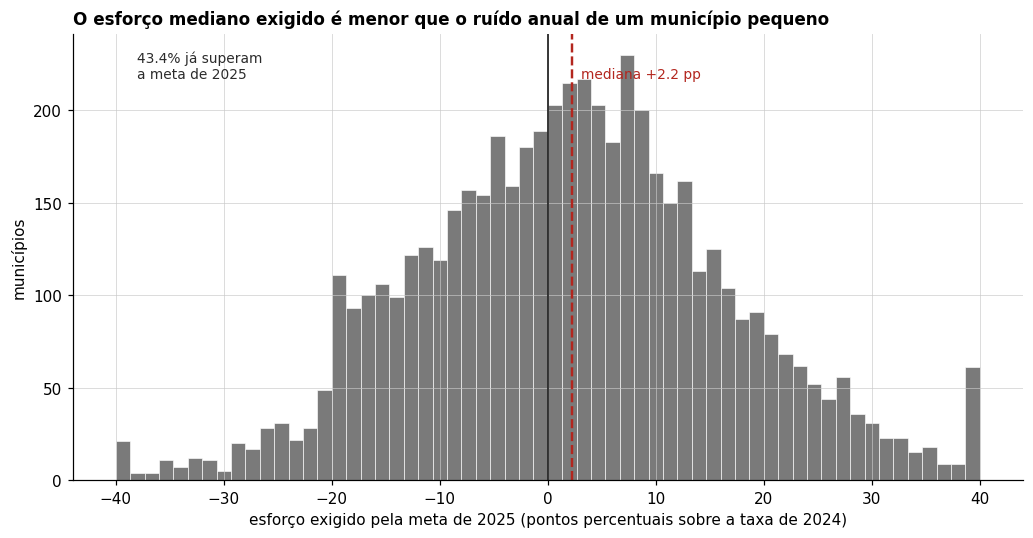

In [9]:
fig = plots.plotar_gap_de_esforco(metas)
print(plots.salvar_figura(fig, "08_gap_de_esforco"))

images/estrategia/09_incerteza_por_porte.png


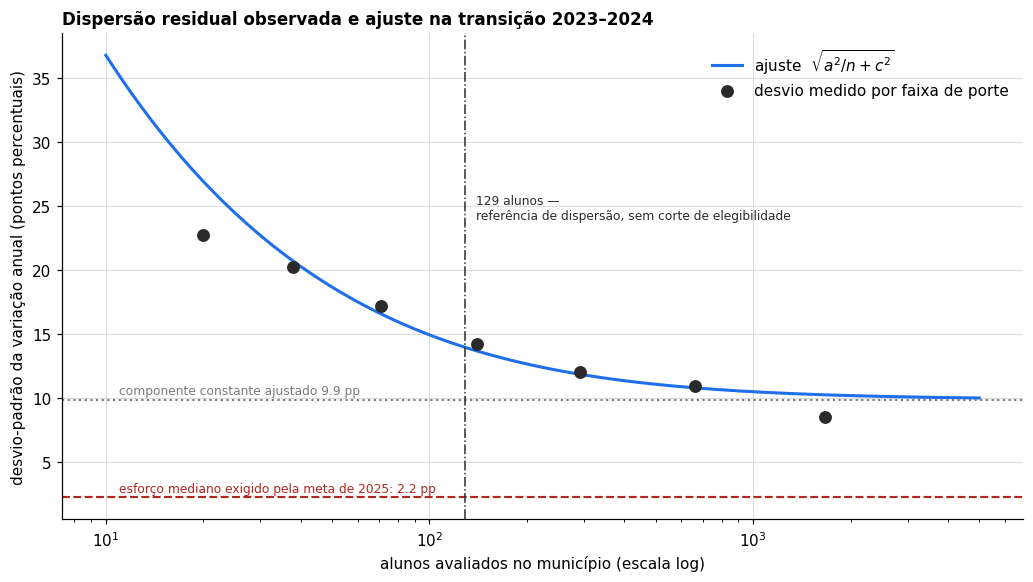

In [10]:
fig = plots.plotar_incerteza_por_porte(pd.read_csv(st.CSV_VOLATILIDADE), resumo)
print(plots.salvar_figura(fig, "09_incerteza_por_porte"))

images/estrategia/10_validacao_metas.png


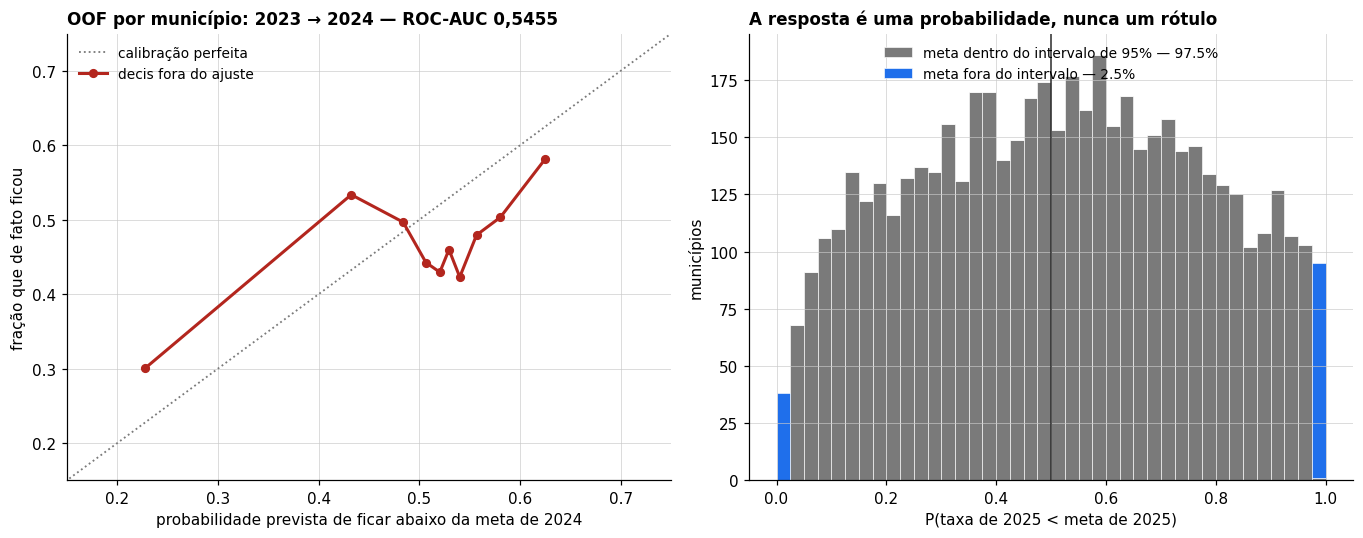

In [11]:
fig = plots.plotar_validacao_metas(pd.read_csv(st.CSV_VALIDACAO_METAS), metas, resumo)
print(plots.salvar_figura(fig, "10_validacao_metas"))

images/estrategia/11_funil_2030.png


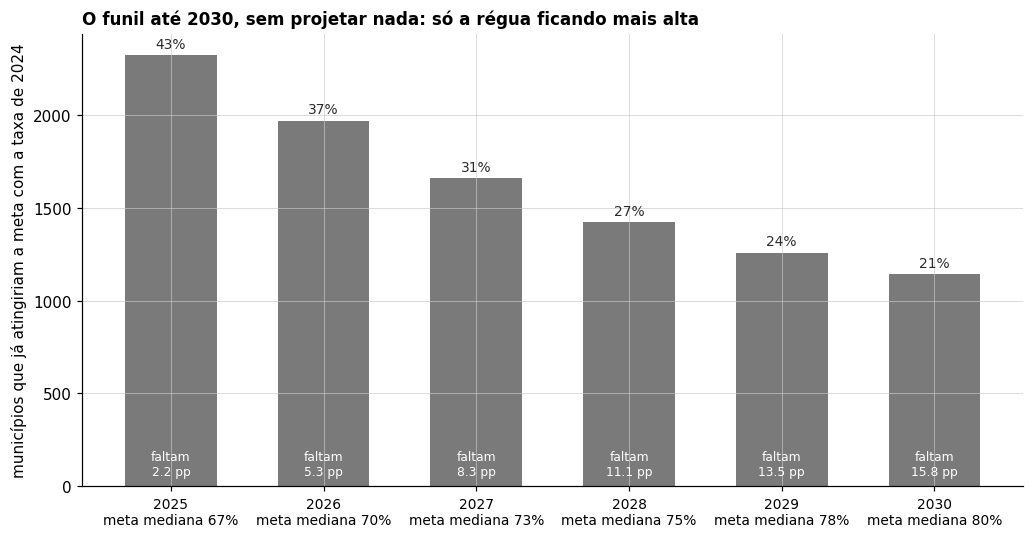

In [12]:
fig = plots.plotar_funil(pd.read_csv(st.CSV_FUNIL))
print(plots.salvar_figura(fig, "11_funil_2030"))